# Illustration Exercise â€” Business Valuation

## Context

A DCF (Discounted Cash Flow) model values a firm as the present value of its
future free cash flows. The terminal value â€” the present value of all cash flows
beyond the explicit forecast period â€” is typically the dominant term and is
extremely sensitive to two parameters: the WACC (discount rate) and the terminal
growth rate $g$. This heatmap shows AAPL's implied enterprise value in $\$B$ across
a grid of (WACC, $g$) combinations, using the most recent free cash flow figure
from `yfinance`. Red cells are low valuations (high discount rates); green cells
are high valuations (low discount rates with higher growth).

## Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
import yfinance as yf
import pathlib, warnings
warnings.filterwarnings("ignore")

plt.style.use(["science", "no-latex"])

aapl = yf.Ticker("AAPL")
cf = aapl.cashflow

# Robustly fetch Operating Cash Flow (row name varies by yfinance version)
ocf, capex = None, None
for name in ["Operating Cash Flow",
             "Total Cash From Operating Activities",
             "Cash From Operating Activities"]:
    if name in cf.index:
        ocf = float(cf.loc[name].iloc[0])
        break

for name in ["Capital Expenditure", "Capital Expenditures",
             "Purchases Of Property Plant And Equipment"]:
    if name in cf.index:
        capex = float(cf.loc[name].iloc[0])
        break

# Fallback to most recent public figures if API names differ
if ocf is None:
    ocf   = 118e9   # AAPL FY2024 approximate OCF
if capex is None:
    capex = -9.5e9  # AAPL FY2024 approximate CapEx (negative in yfinance)

fcf = ocf + capex   # capex is stored as negative
print(f"AAPL Free Cash Flow: ${fcf/1e9:.1f}B")

AAPL Free Cash Flow: $98.8B


## Figure

Saved to C:\Users\jfimb\Documents\book-course-template\book\chapters\05-business-valuation\figures\fig_illustration.pdf


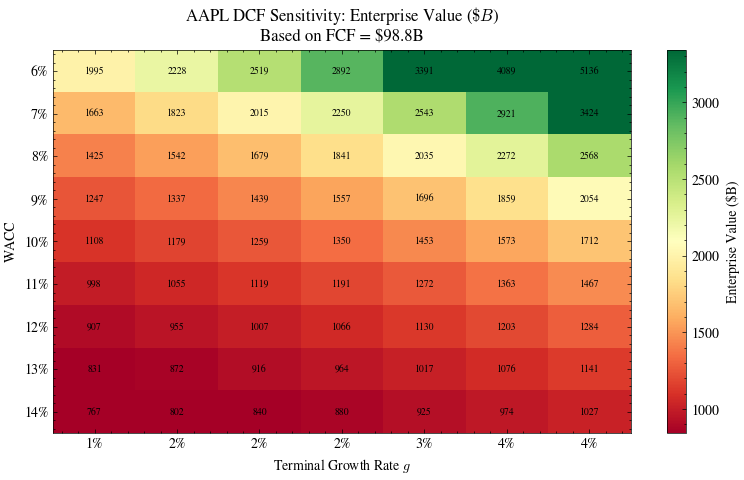

In [2]:
wacc_range = np.linspace(0.06, 0.14, 9)   # 6% â€“ 14%
g_range    = np.linspace(0.01, 0.04, 7)   # 1% â€“ 4%

# Gordon Growth Model terminal value: TV = FCF*(1+g) / (WACC - g)
EV = np.full((len(wacc_range), len(g_range)), np.nan)
for i, w in enumerate(wacc_range):
    for j, g in enumerate(g_range):
        if w > g + 0.005:          # require meaningful spread
            EV[i, j] = fcf * (1 + g) / (w - g) / 1e9

vmin = np.nanpercentile(EV, 5)
vmax = np.nanpercentile(EV, 95)

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(EV, aspect="auto", cmap="RdYlGn", vmin=vmin, vmax=vmax)

ax.set_xticks(range(len(g_range)))
ax.set_xticklabels([f"{g*100:.0f}%" for g in g_range])
ax.set_yticks(range(len(wacc_range)))
ax.set_yticklabels([f"{w*100:.0f}%" for w in wacc_range])
ax.set_xlabel("Terminal Growth Rate $g$")
ax.set_ylabel("WACC")
ax.set_title(f"AAPL DCF Sensitivity: Enterprise Value ($\\$B$)\n"
             f"Based on FCF = \\${fcf/1e9:.1f}B")

for i in range(len(wacc_range)):
    for j in range(len(g_range)):
        if not np.isnan(EV[i, j]):
            ax.text(j, i, f"{EV[i,j]:.0f}",
                    ha="center", va="center", fontsize=7)

plt.colorbar(im, ax=ax, label="Enterprise Value ($B)")
fig.tight_layout()

out_path = pathlib.Path(
    "../../../book/chapters/05-business-valuation/figures/fig_illustration.pdf"
)
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, bbox_inches="tight", dpi=150)
print(f"Saved to {out_path.resolve()}")
plt.show()

## Your Turn

Extend the WACC axis to cover 4%â€“18% and the growth axis to 0%â€“5%.
Identify the (WACC, $g$) combination that produces an enterprise value closest
to AAPL's current market capitalisation (fetch it with
`yf.Ticker("AAPL").info["marketCap"]`). What does this implied (WACC, $g$) pair
tell you about the market's assumptions about Apple?

# Chapter 5: LLMs for Business Valuation â€” Exercises

This notebook contains starter code for the exercises in Lecture 5.
See `course/lectures/05-business-valuation/exercises.md` for full problem statements.

- **Exercise 1 [B]:** EDGAR extraction pipeline
- **Exercise 2 [I]:** FCF forecasting with chain-of-thought prompting
- **Exercise 3 [A]:** Embedding-based comparable selection and valuation

[Placeholder â€” fill in with starter cells as the chapter is drafted]

## Data Lab — SEC EDGAR

Fetch live financial statement data from EDGAR XBRL to power valuation models — no manual data entry required.

In [ ]:
import requests, time, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

EDGAR_HEADERS = {"User-Agent": "LLM-Finance-Course instructor@dauphine.eu"}

def edgar_get(url):
    time.sleep(0.11)
    r = requests.get(url, headers=EDGAR_HEADERS, timeout=15)
    r.raise_for_status()
    return r.json()

def get_cik(ticker):
    data = edgar_get("https://www.sec.gov/files/company_tickers.json")
    for v in data.values():
        if v["ticker"].upper() == ticker.upper():
            return str(v["cik_str"]).zfill(10)
    raise ValueError(f"Ticker {ticker} not found")

def get_submissions(cik):
    return edgar_get(f"https://data.sec.gov/submissions/CIK{cik}.json")

def get_concept(cik, concept):
    return edgar_get(
        f"https://data.sec.gov/api/xbrl/companyconcept/CIK{cik}/us-gaap/{concept}.json")

def get_annual_series(cik, concept):
    data = get_concept(cik, concept)
    usd  = data.get("units", {}).get("USD", [])
    rows = [u for u in usd if u.get("form") == "10-K" and u.get("filed")]
    if not rows:
        for _, vals in data.get("units", {}).items():
            rows = [u for u in vals if u.get("form") == "10-K" and u.get("filed")]
            if rows: break
    df = (pd.DataFrame(rows)[["end","val","filed","accn"]]
            .rename(columns={"end":"date","val":concept})
            .drop_duplicates("date").sort_values("date"))
    df["date"] = pd.to_datetime(df["date"])
    return df

def fetch_10k_html(ticker):
    cik  = get_cik(ticker)
    subs = get_submissions(cik)
    f    = subs["filings"]["recent"]
    idx  = next(i for i, x in enumerate(f["form"]) if x == "10-K")
    acc  = f["accessionNumber"][idx].replace("-", "")
    url  = (f"https://www.sec.gov/Archives/edgar/data/{cik.lstrip('0')}"
            f"/{acc}/{f['primaryDocument'][idx]}")
    time.sleep(0.15)
    return requests.get(url, headers=EDGAR_HEADERS, timeout=30).text

def extract_mda(html):
    text = re.sub(r"<[^>]+>", " ", html)
    m    = re.search(
        r"Item\s+7[.\s]+Management.{0,80}Discussion.*?(?=Item\s+7A|Item\s+8)",
        text, re.IGNORECASE | re.DOTALL)
    raw  = m.group(0) if m else text[:30000]
    return re.sub(r"\s+", " ", raw).strip()

### Exercise [B]: Revenue and Earnings Time Series

In [ ]:
# --- Exercise [B]: Revenue & Earnings Time Series ---
cik_aapl = get_cik("AAPL")
df_rev = get_annual_series(cik_aapl, "Revenues")
df_ni  = get_annual_series(cik_aapl, "NetIncomeLoss")

# Keep last 10 annual observations
df_rev = df_rev.tail(10).set_index("date")
df_ni  = df_ni.tail(10).set_index("date")

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.plot(df_rev.index, df_rev["Revenues"]/1e9, "o-b", label="Revenue ($B)")
ax2.plot(df_ni.index,  df_ni["NetIncomeLoss"]/1e9, "s--r", label="Net Income ($B)")
ax1.set_ylabel("Revenue ($B)", color="b"); ax2.set_ylabel("Net Income ($B)", color="r")
ax1.set_xlabel("Fiscal year end"); ax1.set_title("AAPL Annual Revenue and Net Income")
fig.legend(loc="upper left", bbox_to_anchor=(0.1,0.9)); plt.tight_layout(); plt.show()

def cagr(series, years):
    return (series.iloc[-1] / series.iloc[0]) ** (1/years) - 1

n = len(df_rev) - 1
print(f"Revenue CAGR ({n}yr):    {cagr(df_rev['Revenues'],   n)*100:.1f}%")
print(f"Net Income CAGR ({n}yr): {cagr(df_ni['NetIncomeLoss'], n)*100:.1f}%")

### Exercise [I]: FCF and Gordon Growth Model

In [ ]:
# --- Exercise [I]: FCF & Gordon Growth Model ---
df_ocf  = get_annual_series(cik_aapl, "NetCashProvidedByUsedInOperatingActivities")
df_capex= get_annual_series(cik_aapl, "PaymentsToAcquirePropertyPlantAndEquipment")

df_fcf = df_ocf.tail(5).set_index("date").copy()
df_fcf["CapEx"] = df_capex.tail(5).set_index("date")["PaymentsToAcquirePropertyPlantAndEquipment"]
df_fcf["FCF"]   = df_fcf["NetCashProvidedByUsedInOperatingActivities"] - df_fcf["CapEx"]

fig, ax = plt.subplots(figsize=(8,4))
ax.bar(range(len(df_fcf)), df_fcf["FCF"]/1e9, color="steelblue")
ax.set_xticks(range(len(df_fcf))); ax.set_xticklabels([str(d.year) for d in df_fcf.index])
ax.set_ylabel("FCF ($B)"); ax.set_title("AAPL Free Cash Flow"); plt.tight_layout(); plt.show()

fcf0      = df_fcf["FCF"].iloc[-1]
wacc_rng  = np.linspace(0.06, 0.14, 9)
g_rng     = np.linspace(0.01, 0.04, 7)
EV        = np.full((len(wacc_rng), len(g_rng)), np.nan)
for i, w in enumerate(wacc_rng):
    for j, g in enumerate(g_rng):
        if w > g + 0.005:
            EV[i,j] = fcf0 * (1+g) / (w-g) / 1e9

fig, ax = plt.subplots(figsize=(8,5))
im = ax.imshow(EV, cmap="RdYlGn", vmin=np.nanpercentile(EV,5), vmax=np.nanpercentile(EV,95))
ax.set_xticks(range(len(g_rng))); ax.set_xticklabels([f"{g*100:.0f}%" for g in g_rng])
ax.set_yticks(range(len(wacc_rng))); ax.set_yticklabels([f"{w*100:.0f}%" for w in wacc_rng])
ax.set_xlabel("Terminal growth g"); ax.set_ylabel("WACC")
ax.set_title(f"AAPL Gordon Growth EV ($B), FCF=${fcf0/1e9:.0f}B")
for i in range(len(wacc_rng)):
    for j in range(len(g_rng)):
        if not np.isnan(EV[i,j]):
            ax.text(j,i,f"{EV[i,j]:.0f}",ha="center",va="center",fontsize=7)
plt.colorbar(im, label="EV ($B)"); plt.tight_layout(); plt.show()

try:
    import yfinance as yf
    mktcap = yf.Ticker("AAPL").info.get("marketCap", None)
    if mktcap:
        print(f"AAPL market cap: ${mktcap/1e9:.0f}B")
except:
    print("yfinance not available for market cap comparison")

### Exercise [A]: Five-Company DCF Comparison

In [ ]:
# --- Exercise [A]: Five-Company DCF Comparison ---
TICKERS_05A = {"AAPL":0.09,"MSFT":0.09,"GOOGL":0.10,"AMZN":0.11,"META":0.11}
G_TERMINAL  = 0.03
rows_dcf    = []

for t, wacc in TICKERS_05A.items():
    try:
        cik = get_cik(t)
        ocf  = get_annual_series(cik, "NetCashProvidedByUsedInOperatingActivities")["NetCashProvidedByUsedInOperatingActivities"].iloc[-1]
        capex= get_annual_series(cik, "PaymentsToAcquirePropertyPlantAndEquipment")["PaymentsToAcquirePropertyPlantAndEquipment"].iloc[-1]
        fcf  = ocf - capex
        ev   = fcf * (1+G_TERMINAL) / (wacc - G_TERMINAL) / 1e9
        try:
            import yfinance as yf
            mc = yf.Ticker(t).info.get("marketCap", None)
            mc = mc/1e9 if mc else None
        except: mc = None
        rows_dcf.append({"ticker":t,"fcf_b":fcf/1e9,"ev_b":ev,"mktcap_b":mc,"wacc":wacc})
        print(f"{t}: FCF=${fcf/1e9:.1f}B  EV=${ev:.0f}B  MktCap=${mc:.0f}B" if mc else f"{t}: FCF=${fcf/1e9:.1f}B  EV=${ev:.0f}B")
    except Exception as e:
        print(f"{t}: {e}")

df_dcf = pd.DataFrame(rows_dcf).set_index("ticker")
fig, ax = plt.subplots(figsize=(9,5))
x = np.arange(len(df_dcf))
w = 0.35
ax.barh(x-w/2, df_dcf["ev_b"],     w, label="Implied EV",   color="steelblue")
ax.barh(x+w/2, df_dcf["mktcap_b"], w, label="Market Cap",   color="tomato")
ax.set_yticks(x); ax.set_yticklabels(df_dcf.index)
ax.set_xlabel("Value ($B)"); ax.set_title("DCF Implied EV vs. Market Cap")
ax.legend(); plt.tight_layout(); plt.show()